# Unsupervised Discovery: Wafer Defect Pattern Recognition## K-Means, DBSCAN & PCA on Post-Silicon Wafer Maps**Project:** 006 — The AI Engineering Lab  **Objective:** Discover spatial defect patterns in semiconductor wafer data without labels.  **Advanced Concepts:** PCA biplot, GMM comparison, cluster-centroid analysis.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data8,000 wafer defect observations with spatial and electrical features.

In [2]:
df = pd.read_csv('../data/wafer_defect_patterns.csv')
print(f'Shape: {df.shape}')
print(f'Patterns (hidden): {df["true_pattern"].unique().tolist()}')
df.describe().round(3)

Shape: (8000, 7)
Patterns (hidden): ['Random', 'Edge Ring', 'Scratch', 'Center Spot', 'Local Cluster', 'Donut']


,x_coord,y_coord,defect_density,particle_size_um,electrical_fail_rate,distance_from_center
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,0.125,0.124,0.485,1.028,0.418,0.604
std,0.468,0.449,0.299,0.610,0.271,0.295
min,-0.998,-0.992,0.000,0.100,0.000,0.000
25%,-0.186,-0.156,0.134,0.573,0.080,0.400
50%,0.136,0.126,0.584,0.890,0.509,0.665
75%,0.525,0.505,0.722,1.299,0.635,0.865
max,0.999,0.999,1.000,4.228,0.962,1.190


In [3]:
y_true = df['true_pattern']
X = df.drop(columns=['true_pattern'])
feature_names = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features: {feature_names}')
print(f'Distribution:\n{y_true.value_counts().to_string()}')

Features: ['x_coord', 'y_coord', 'defect_density', 'particle_size_um', 'electrical_fail_rate', 'distance_from_center']
Distribution:
true_pattern
Random           2500
Local Cluster    1900
Edge Ring        1200
Donut            1000
Center Spot       800
Scratch           600


---## 3. EDA

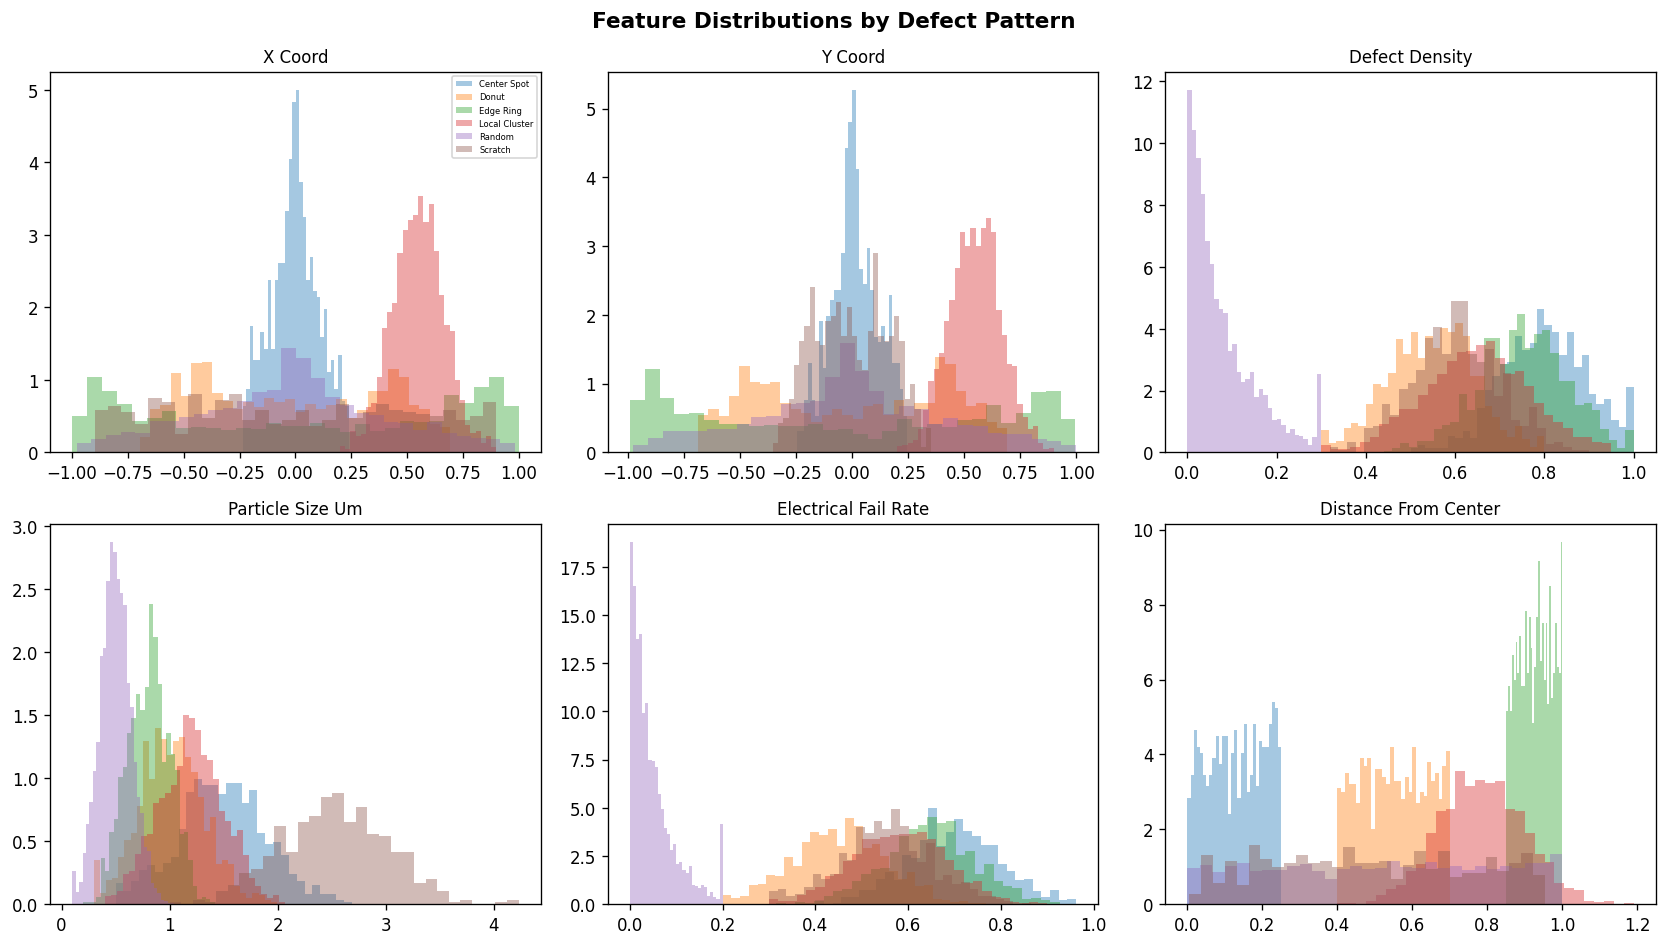

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(feature_names):
    ax = axes[i // 3, i % 3]
    for pat in sorted(y_true.unique()):
        ax.hist(df[y_true == pat][col], bins=30, alpha=0.4, label=pat, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    if i == 0:
        ax.legend(fontsize=5)
plt.suptitle('Feature Distributions by Defect Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/eda_wafer_defects.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. PCA & Biplot

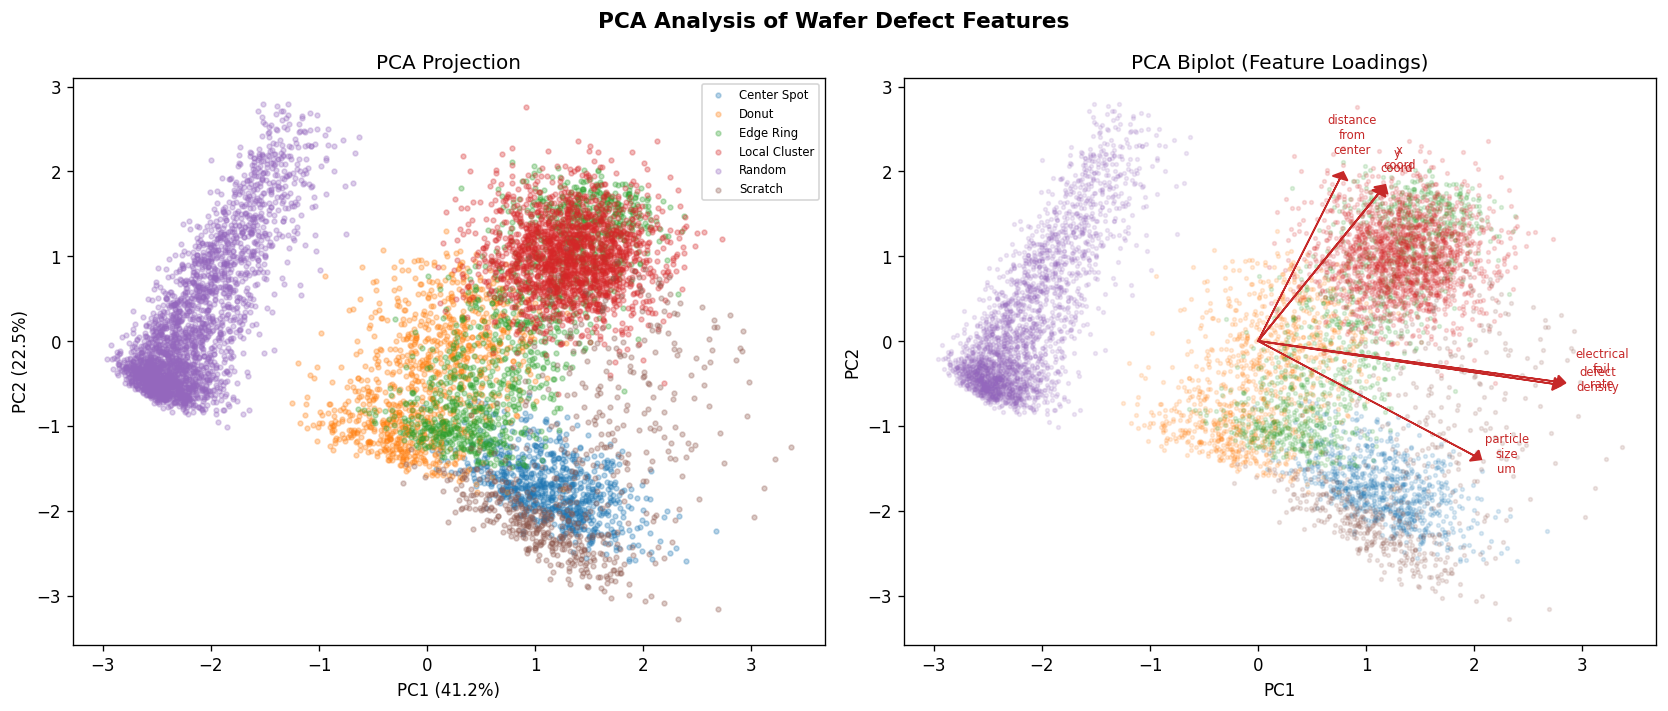

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for pat in sorted(y_true.unique()):
    mask = y_true == pat
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=8, label=pat)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA Projection'); axes[0].legend(fontsize=7)

for pat in sorted(y_true.unique()):
    mask = y_true == pat
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.15, s=5)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
scale = 3
for j, fname in enumerate(feature_names):
    axes[1].arrow(0, 0, loadings[j, 0]*scale, loadings[j, 1]*scale,
                  head_width=0.15, head_length=0.08, fc=COLORS['highlight'], ec=COLORS['highlight'])
    axes[1].text(loadings[j, 0]*scale*1.15, loadings[j, 1]*scale*1.15,
                 fname.replace('_', '\n'), fontsize=7, ha='center', color=COLORS['highlight'])
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA Biplot (Feature Loadings)')
plt.suptitle('PCA Analysis of Wafer Defect Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/pca_wafer.png', dpi=150, bbox_inches='tight')
plt.show()

---## 5. K-Means

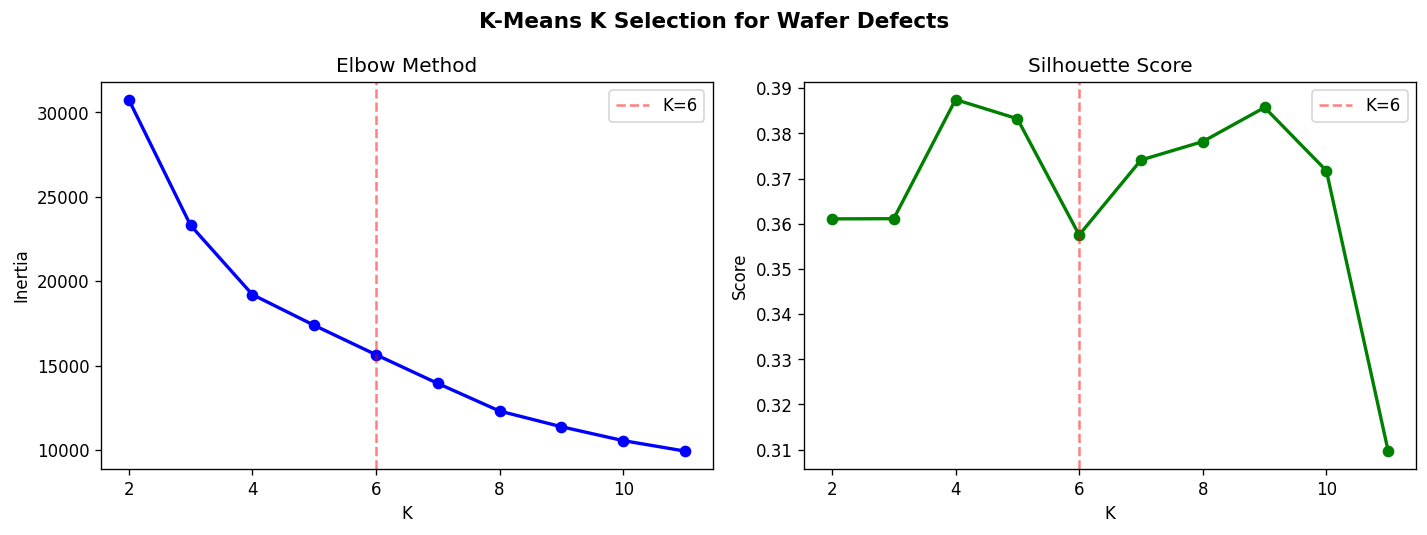

K-Means ARI: 0.568


Silhouette: 0.358


In [6]:
K_range = range(2, 12)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].legend()
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].legend()
plt.suptitle('K-Means K Selection for Wafer Defects', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

km_final = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_scaled)
print(f'K-Means ARI: {adjusted_rand_score(y_true, km_labels):.3f}')
print(f'Silhouette: {silhouette_score(X_scaled, km_labels):.3f}')

---## 6. DBSCAN & GMM

In [7]:
db = DBSCAN(eps=2.0, min_samples=10)
db_labels = db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct = (db_labels == -1).sum() / len(db_labels) * 100

gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

print(f'DBSCAN: {n_clusters_db} clusters, {noise_pct:.1f}% noise, ARI={adjusted_rand_score(y_true, db_labels):.3f}')
print(f'GMM: ARI={adjusted_rand_score(y_true, gmm_labels):.3f}, BIC={gmm.bic(X_scaled):.0f}')

DBSCAN: 1 clusters, 0.0% noise, ARI=0.000
GMM: ARI=0.583, BIC=72612


---## 7. Three-Way Comparison

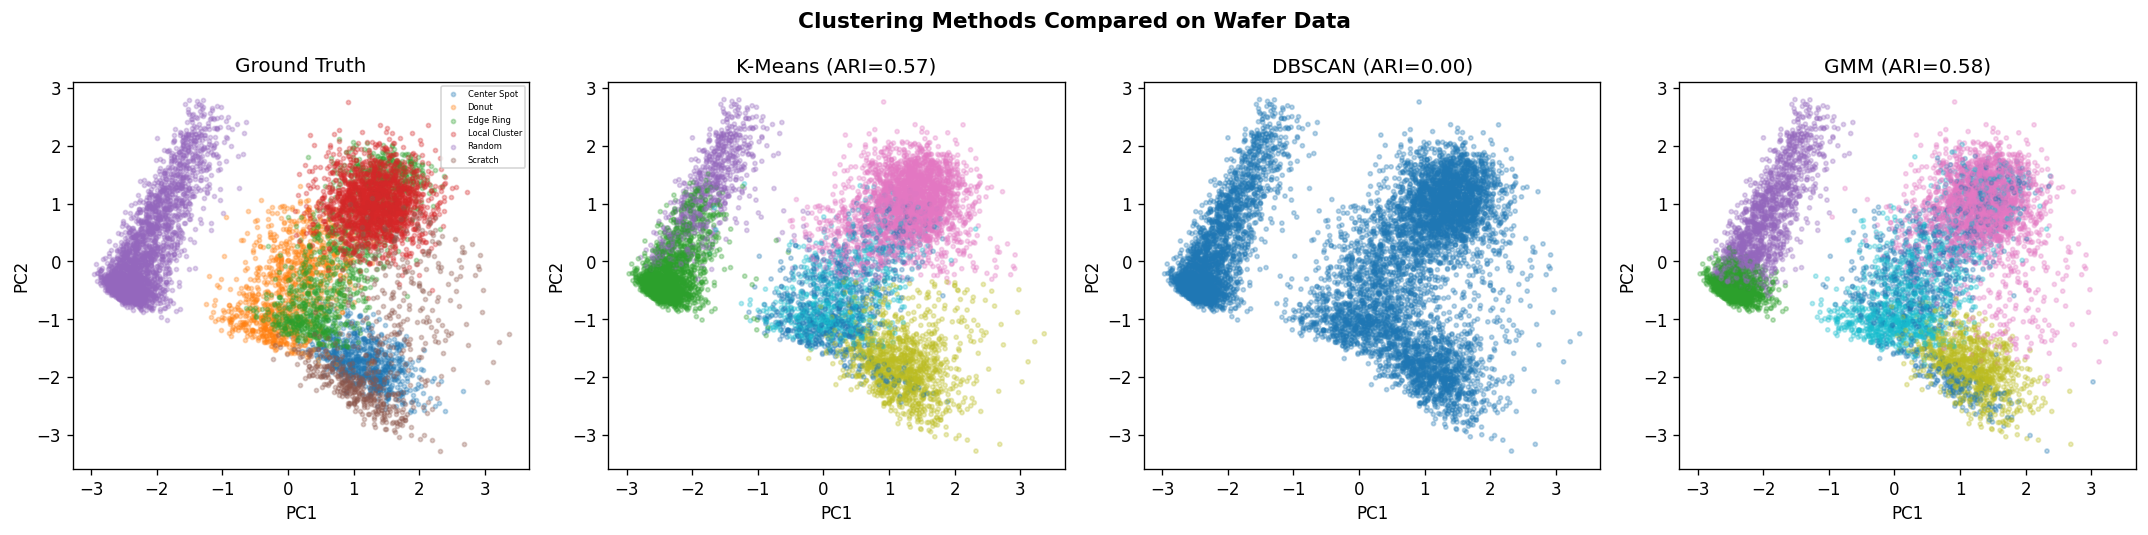

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for pat in sorted(y_true.unique()):
    mask = y_true == pat
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=6, label=pat)
axes[0].set_title('Ground Truth'); axes[0].legend(fontsize=5)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='tab10', alpha=0.3, s=6)
axes[1].set_title(f'K-Means (ARI={adjusted_rand_score(y_true, km_labels):.2f})')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', alpha=0.3, s=6)
axes[2].set_title(f'DBSCAN (ARI={adjusted_rand_score(y_true, db_labels):.2f})')

axes[3].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10', alpha=0.3, s=6)
axes[3].set_title(f'GMM (ARI={adjusted_rand_score(y_true, gmm_labels):.2f})')

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Clustering Methods Compared on Wafer Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/wafer_clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
results = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN', 'GMM'],
    'Clusters': [6, n_clusters_db, 6],
    'ARI': [round(adjusted_rand_score(y_true, km_labels), 3),
            round(adjusted_rand_score(y_true, db_labels), 3),
            round(adjusted_rand_score(y_true, gmm_labels), 3)]
})
print(results.to_string(index=False))
print('\nNotebook complete.')

 Method  Clusters   ARI
K-Means         6 0.568
 DBSCAN         1 0.000
    GMM         6 0.583

Notebook complete.
